In [2]:
# ============================================================
# Confronto finale tra tutti i metodi (TV, UNet, Weighted TV)
# Legge i riepiloghi JSON e le ricostruzioni gia' salvate dagli
# altri notebook, non ricalcola nulla da zero.
# ============================================================

from pathlib import Path
import json
import random

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

from IPPy.utilities.metrics import PSNR, SSIM
from utils.data_utils import load_normalized_image


# Ricostruzioni (root/n_angoli/paziente/slice.npy, stessa struttura per tutti e tre)
TEST_DIR = Path("../dataset_resized/test_resized")
TV_TEST_DIR = Path("../tv_reconstructions/test")
WTV_TEST_DIR = Path("../weighted_tv_reconstructions_tuned/test")
UNET_TEST_DIR = Path("../unet_reconstructions/test")

RESULTS_DIR = Path("../results")
JSON_DIR = RESULTS_DIR / "json"

FINAL_DIR = RESULTS_DIR / "final_comparison"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

N_ANGLES_CONFIGS = [90, 45, 30, 15]

ANGLE_INTERVALS = {
    90: "[-45°, 45°]",
    45: "[-45°, 45°]",
    30: "(-30°, 30°)",
    15: "(-30°, 30°)",
}

# Il TV e' stato valutato solo sul paziente C081: e' l'unico paziente
# comune a tutti e tre i metodi, va usato per il confronto visivo
PATIENT = "C081"

# Solo i metodi confrontati contro la ground truth (metrica finale)
METHODS_JSON = {
    "TV": JSON_DIR / "tv_test_metrics.json",
    "UNet": JSON_DIR / "unet_test_metrics.json",
    "Weighted TV": JSON_DIR / "weighted_tv_tuned_test_metrics.json",
}

# Cartella di ricostruzione corrispondente a ciascun metodo, usata
# solo per il confronto visivo (le metriche vengono dai JSON sopra)
METHOD_DIRS = {
    "TV": TV_TEST_DIR,
    "UNet": UNET_TEST_DIR,
    "Weighted TV": WTV_TEST_DIR,
}


In [3]:
# ============================================================
# Caricamento dei riepiloghi JSON e costruzione della tabella finale
# ============================================================

metrics_by_method = {}
for method, path in METHODS_JSON.items():
    with open(path) as f:
        metrics_by_method[method] = json.load(f)

rows = []
for method, metrics in metrics_by_method.items():
    for n_angles in N_ANGLES_CONFIGS:
        m = metrics[str(n_angles)]
        rows.append({
            "Metodo": method,
            "N angoli": n_angles,
            "Intervallo": ANGLE_INTERVALS[n_angles],
            "PSNR medio (dB)": round(m["psnr_mean"], 2),
            "PSNR std": round(m["psnr_std"], 2),
            "SSIM medio": round(m["ssim_mean"], 4),
            "SSIM std": round(m["ssim_std"], 4),
            "N slice": m["n_slices"],
        })

summary_df = pd.DataFrame(rows)
summary_df = summary_df.sort_values(["N angoli", "Metodo"], ascending=[False, True]).reset_index(drop=True)
summary_df


,Metodo,N angoli,Intervallo,PSNR medio (dB),PSNR std,SSIM medio,SSIM std,N slice
0,TV,90,"[-45°, 45°]",23.83,2.12,0.7257,0.0502,327
1,UNet,90,"[-45°, 45°]",23.35,1.64,0.7189,0.0385,327
2,Weighted TV,90,"[-45°, 45°]",24.06,2.10,0.7376,0.0448,327
3,TV,45,"[-45°, 45°]",23.79,2.14,0.7221,0.0505,327
4,UNet,45,"[-45°, 45°]",23.32,1.48,0.7153,0.0376,327
5,Weighted TV,45,"[-45°, 45°]",23.94,2.07,0.7309,0.0445,327
6,TV,30,"(-30°, 30°)",21.75,2.35,0.6426,0.0605,327
7,UNet,30,"(-30°, 30°)",21.15,1.98,0.6250,0.0579,327
8,Weighted TV,30,"(-30°, 30°)",21.91,2.36,0.6506,0.0587,327
9,TV,15,"(-30°, 30°)",21.51,2.37,0.6231,0.0644,327


In [4]:
# ============================================================
# Controllo: il TV e' stato valutato solo sul paziente C081, gli
# altri metodi sul test set completo. Numero di slice diverso tra
# metodi -> tenerne conto confrontando le medie.
# ============================================================

for n_angles in N_ANGLES_CONFIGS:
    n_slices = {method: metrics_by_method[method][str(n_angles)]["n_slices"] for method in metrics_by_method}
    if len(set(n_slices.values())) > 1:
        print(f"{n_angles} angoli -> numero di slice diverso tra metodi: {n_slices}")


In [5]:
# ============================================================
# Salvataggio tabella riassuntiva in CSV
# ============================================================

out_path = FINAL_DIR / "final_metrics_summary.csv"
summary_df.to_csv(out_path, index=False)
print(f"Tabella salvata in: {out_path}")


Tabella salvata in: ..\results\final_comparison\final_metrics_summary.csv


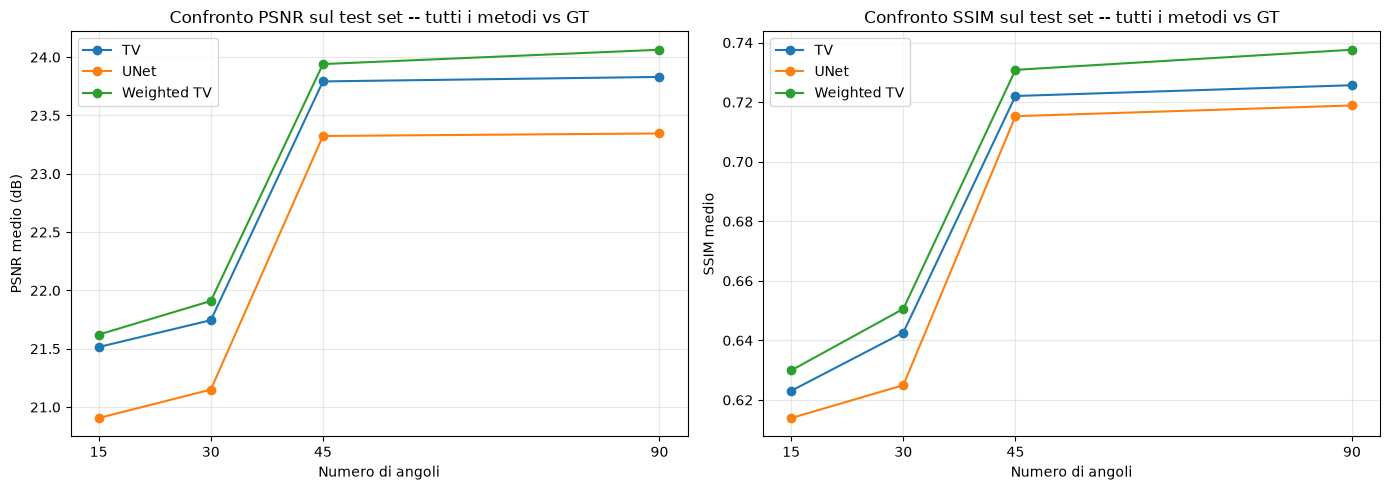

In [6]:
# ============================================================
# Grafico comparativo PSNR e SSIM medi, tutti i metodi vs GT
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for method, metrics in metrics_by_method.items():
    psnr_means = [metrics[str(n)]["psnr_mean"] for n in N_ANGLES_CONFIGS]
    ssim_means = [metrics[str(n)]["ssim_mean"] for n in N_ANGLES_CONFIGS]

    axs[0].plot(N_ANGLES_CONFIGS, psnr_means, marker="o", label=method)
    axs[1].plot(N_ANGLES_CONFIGS, ssim_means, marker="o", label=method)

axs[0].set_xlabel("Numero di angoli")
axs[0].set_ylabel("PSNR medio (dB)")
axs[0].set_title("Confronto PSNR sul test set -- tutti i metodi vs GT")
axs[0].set_xticks(N_ANGLES_CONFIGS)
axs[0].grid(alpha=0.3)
axs[0].legend()

axs[1].set_xlabel("Numero di angoli")
axs[1].set_ylabel("SSIM medio")
axs[1].set_title("Confronto SSIM sul test set -- tutti i metodi vs GT")
axs[1].set_xticks(N_ANGLES_CONFIGS)
axs[1].grid(alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.savefig(FINAL_DIR / "comparison_psnr_ssim_all_methods.png", dpi=150)
plt.show()


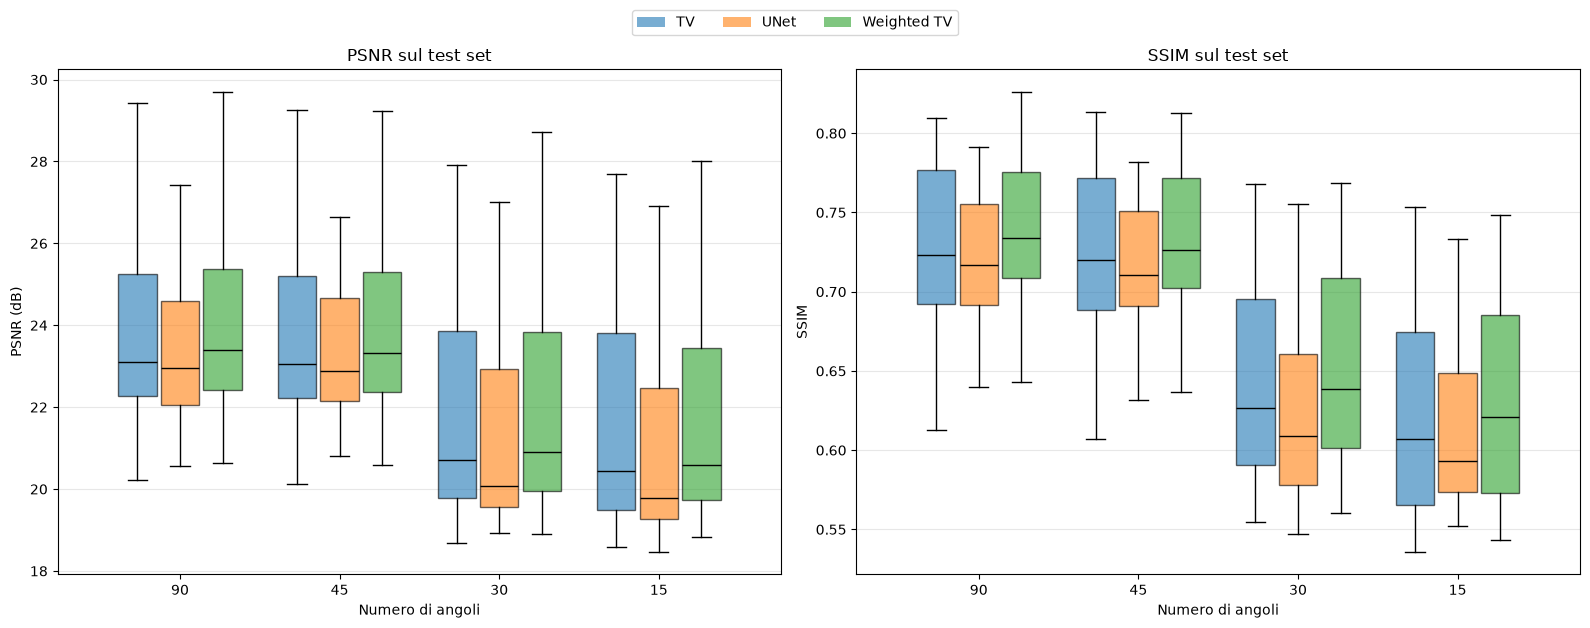

In [7]:
# ============================================================
# Boxplot PSNR e SSIM sull'intero test set, per metodo e
# configurazione -- richiesto dalla consegna (distribuzione su
# tutte le slice, non solo la media aggregata della cella sopra)
# ============================================================

methods = list(metrics_by_method.keys())
n_methods = len(methods)
width = 0.8 / n_methods

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

for m_idx, method in enumerate(methods):
    psnr_data = [metrics_by_method[method][str(n)]["psnr_values"] for n in N_ANGLES_CONFIGS]
    ssim_data = [metrics_by_method[method][str(n)]["ssim_values"] for n in N_ANGLES_CONFIGS]

    positions = [i + (m_idx - (n_methods - 1) / 2) * width for i in range(len(N_ANGLES_CONFIGS))]

    axs[0].boxplot(
        psnr_data, positions=positions, widths=width * 0.9,
        patch_artist=True, showfliers=False,
        boxprops=dict(facecolor=f"C{m_idx}", alpha=0.6),
        medianprops=dict(color="black"),
    )
    axs[1].boxplot(
        ssim_data, positions=positions, widths=width * 0.9,
        patch_artist=True, showfliers=False,
        boxprops=dict(facecolor=f"C{m_idx}", alpha=0.6),
        medianprops=dict(color="black"),
    )

for ax, title, ylabel in [
    (axs[0], "PSNR sul test set", "PSNR (dB)"),
    (axs[1], "SSIM sul test set", "SSIM"),
]:
    ax.set_xticks(range(len(N_ANGLES_CONFIGS)))
    ax.set_xticklabels([str(n) for n in N_ANGLES_CONFIGS])
    ax.set_xlabel("Numero di angoli")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3, axis="y")

# I boxplot non generano una legenda automatica per gruppo: la costruiamo a mano
legend_handles = [plt.Rectangle((0, 0), 1, 1, facecolor=f"C{i}", alpha=0.6) for i in range(n_methods)]
fig.legend(legend_handles, methods, loc="upper center", ncol=n_methods, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.savefig(FINAL_DIR / "boxplot_psnr_ssim_all_methods.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
# ============================================================
# Selezione della slice di esempio (paziente C081, comune a tutti
# e tre i metodi) per il confronto visivo finale
# ============================================================

def load_recon(path: Path) -> np.ndarray:
    return np.clip(np.load(path).astype(np.float32), 0.0, 1.0)


random.seed(123)

GT_DIR = TEST_DIR / PATIENT
gt_paths = sorted(GT_DIR.glob("*.png"), key=lambda p: int(p.stem))
demo_path = random.choice(gt_paths)
slice_name = demo_path.stem

print(f"Slice scelta per il confronto finale: paziente {PATIENT}, slice {slice_name}")

gt = load_normalized_image(demo_path)
gt_t = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)


Slice scelta per il confronto finale: paziente C081, slice 26


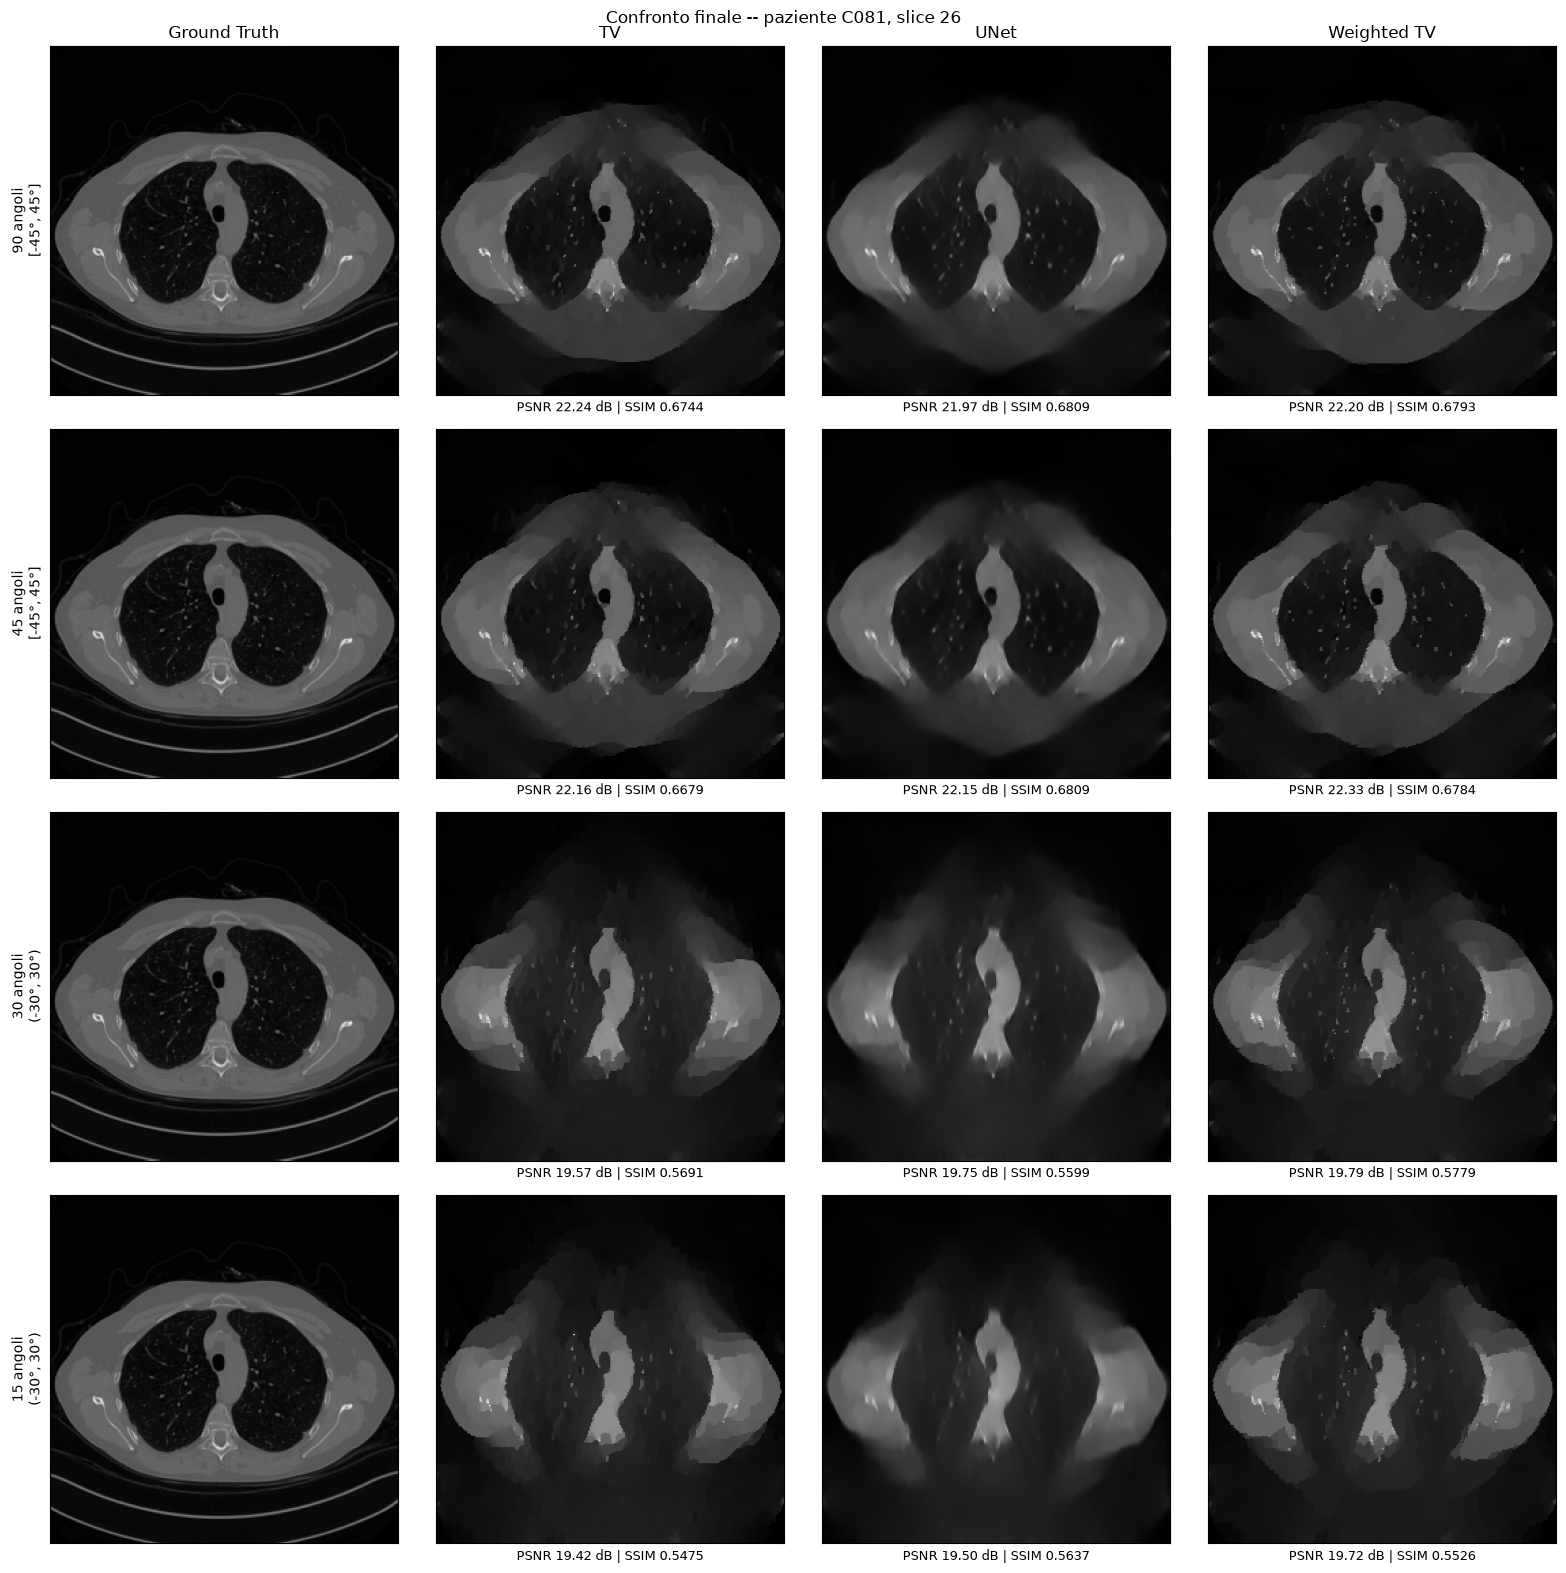

In [9]:
# ============================================================
# Confronto visivo finale: Ground Truth + tutti i metodi, stessa
# slice, tutte le configurazioni angolari
# ============================================================

fig, axs = plt.subplots(
    len(N_ANGLES_CONFIGS), len(METHOD_DIRS) + 1,
    figsize=(4 * (len(METHOD_DIRS) + 1), 4 * len(N_ANGLES_CONFIGS)),
)

for row, n_angles in enumerate(N_ANGLES_CONFIGS):

    axs[row, 0].imshow(gt, cmap="gray", vmin=0, vmax=1)
    axs[row, 0].set_ylabel(f"{n_angles} angoli\n{ANGLE_INTERVALS[n_angles]}", fontsize=10)
    if row == 0:
        axs[row, 0].set_title("Ground Truth")
    axs[row, 0].set_xticks([]); axs[row, 0].set_yticks([])

    for col, (method, method_dir) in enumerate(METHOD_DIRS.items(), start=1):
        recon_path = method_dir / str(n_angles) / PATIENT / f"{slice_name}.npy"
        recon = load_recon(recon_path)
        recon_t = torch.from_numpy(recon).float().unsqueeze(0).unsqueeze(0)

        psnr_val = float(PSNR(recon_t, gt_t))
        ssim_val = float(SSIM(recon_t, gt_t))

        axs[row, col].imshow(recon, cmap="gray", vmin=0, vmax=1)
        if row == 0:
            axs[row, col].set_title(method)
        axs[row, col].set_xlabel(f"PSNR {psnr_val:.2f} dB | SSIM {ssim_val:.4f}", fontsize=9)
        axs[row, col].set_xticks([]); axs[row, col].set_yticks([])

plt.suptitle(f"Confronto finale -- paziente {PATIENT}, slice {slice_name}")
plt.tight_layout()
plt.savefig(FINAL_DIR / "final_visual_comparison_all_methods.png", dpi=150)
plt.show()
